In [1]:
import sys
from pathlib import Path
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import Data
import Imaging, Autofocus
from scipy.signal import find_peaks

In [2]:
RESOLUTION = (100, 100) # pixels
DYNAMIC_RANGE_DB = 10.0 # dB

radar = Data.MITRadar(filename="/Users/levifarinas/Library/Mobile Documents/com~apple~CloudDocs/Projects/SAR Backprojection/SAR Data/UXOClass_020226_Groupandrew_experiment1_caponly.wav")
rp, positions, dr = radar.compute_range_profiles()

focus_img, unfocused_img, phase_error = Autofocus.pga(
    positions=positions,
    range_profiles=rp,
    base_parameters={
        "crossrange": (-10 * radar.FT, 10 * radar.FT),
        "downrange": (0 * radar.FT, 25 * radar.FT),
        "resolution": RESOLUTION,
        "fstart": radar.FSTART,
        "fstop": radar.FSTOP,
        "phase_sign": -1.0,
        "output_db": True,
        "normalize_db": True,
        "flip_lr": False,
        "flip_ud": False,
        "transpose_output": False,
        "os_factor": radar.IMAGE_OVERSAMPLE,
        "dr": dr,
        "x_scale": 1.0,
        "x_offset": 0.0,
        "y_offset": 0.0,
        "z_offset": 0.0,
        "cable_off_ft": radar.CALIBRATION_OFFSET
    })

# img0, crossrange_axis, downrange_axis, phase_hist = Imaging.backproject(
#     positions=positions,
#     range_profiles=rp,
#     crossrange=(-10 * radar.FT, 10 * radar.FT),
#     downrange=(0 * radar.FT, 25 * radar.FT),
#     resolution=RESOLUTION,
#     fstart=radar.FSTART,
#     fstop=radar.FSTOP,
#     phase_sign=-1.0,
#     output_db=True,
#     normalize_db=True,
#     flip_lr=False,
#     flip_ud=False,
#     transpose_output=False,
#     os_factor=radar.IMAGE_OVERSAMPLE,
#     dr=dr,
#     x_scale=1.0,
#     x_offset=0.0,
#     y_offset=0.0,
#     z_offset=0.0,
#     cable_off_ft=radar.CALIBRATION_OFFSET,
#     pga=True
# )

Processing: /Users/levifarinas/Library/Mobile Documents/com~apple~CloudDocs/Projects/SAR Backprojection/SAR Data/UXOClass_020226_Groupandrew_experiment1_caponly.wav


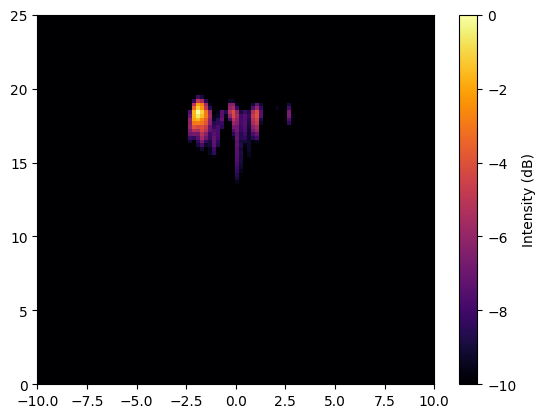

In [4]:
plt.imshow(focus_img, extent=(-10, 10, 0, 25), aspect='auto', cmap='inferno', vmin=-DYNAMIC_RANGE_DB, vmax=0)
plt.colorbar(label='Intensity (dB)')

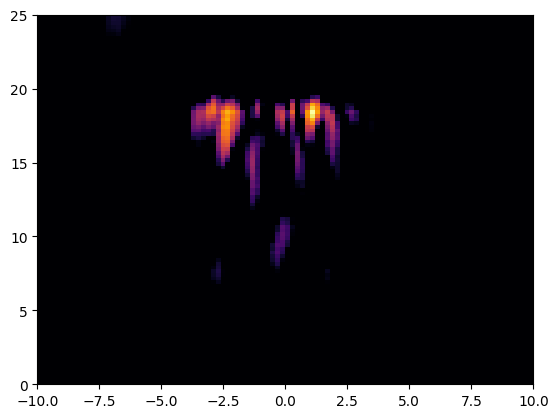

In [6]:
plt.imshow(unfocused_img, extent=(-10, 10, 0, 25), aspect='auto', cmap='inferno', vmin=-DYNAMIC_RANGE_DB, vmax=0)